In [1]:
import pandas as pd
import os
from collections import defaultdict

os.chdir('/data2/zhoulab/fanweiliang/mouse_IER1_splicing')

all_introns = pd.read_table('results/hela_tm_tg_mix/stringtie_viral_porechopabi/merged.splice_sites.with_types.tsv')
nc_introns = all_introns[all_introns['splice_type'] == 'NC']
nc_introns_dict = defaultdict(list)
for idx, row in nc_introns.iterrows():
    nc_introns_dict[f'{row["chr"]}_{row["strand"]}'].append(f'{row["start"]}-{row["end"]}')

all_transcripts = pd.read_table(
    'results/hela_tm_tg_mix/stringtie_viral_porechopabi/merged.transcript_intron_regions.tsv',
    header=None, names=['transcript_id', 'chr', 'strand', 'intron_regions'],
    dtype={'transcript_id': str, 'chr': str, 'strand': str, 'intron_regions': str}
)

# Remove transcripts without intron regions (single-exon transcripts)
all_transcripts.dropna(subset=['intron_regions'], inplace=True)

def check_whether_contains_nc_introns(row):
    for intron_region in row['intron_regions'].split(';'):
        if intron_region in nc_introns_dict[f'{row["chr"]}_{row["strand"]}']:
            return True
    return False

nc_transcripts = all_transcripts[all_transcripts.apply(check_whether_contains_nc_introns, axis=1)]
nc_transcripts.head(10)


,transcript_id,chr,strand,intron_regions
2,MSTRG.3.1,GL000009.2,+,56085-122563
7,MSTRG.8.1,GL000218.1,+,48143-95173
8,MSTRG.8.2,GL000218.1,+,89059-95173
12,MSTRG.11.2,GL000220.1,-,121701-121827
16,MSTRG.15.1,GL000250.2,-,1319767-1320013;1320115-1320320;1320432-1322764
19,MSTRG.18.1,GL000250.2,-,170250-172819;172847-174391;174425-174556;1746...
20,MSTRG.19.1,GL000250.2,+,170250-172819;172847-174391
21,MSTRG.19.2,GL000250.2,+,170250-172819;172847-174391;174425-174556;1746...
24,MSTRG.22.1,GL000250.2,-,1325572-1326681;1326791-1327195
25,MSTRG.23.1,GL000250.2,+,2000779-2002138


In [2]:
import os

os.chdir('/data2/zhoulab/fanweiliang/mouse_IER1_splicing')

nc_transcripts_ids = []
nc_ids_cache = 'results/hela_tm_tg_mix/stringtie_viral_porechopabi/nc_transcripts_ids.txt'
if os.path.exists(nc_ids_cache):
    with open(nc_ids_cache, 'r') as f:
        nc_transcripts_ids = [line.strip() for line in f]
else:
    nc_transcripts_ids = nc_transcripts['transcript_id'].tolist()
    with open(nc_ids_cache, 'w') as f:
        for transcript_id in nc_transcripts_ids:
            f.write(transcript_id + '\n')

print(nc_transcripts_ids[:20])
print(f'Number of transcripts containing NC introns: {len(nc_transcripts_ids)}')

['MSTRG.3.1', 'MSTRG.8.1', 'MSTRG.8.2', 'MSTRG.11.2', 'MSTRG.15.1', 'MSTRG.18.1', 'MSTRG.19.1', 'MSTRG.19.2', 'MSTRG.22.1', 'MSTRG.23.1', 'MSTRG.28.1', 'MSTRG.30.1', 'MSTRG.31.1', 'MSTRG.31.2', 'MSTRG.33.1', 'MSTRG.34.1', 'MSTRG.37.1', 'MSTRG.38.1', 'MSTRG.40.1', 'MSTRG.40.2']
Number of transcripts containing NC introns: 6729


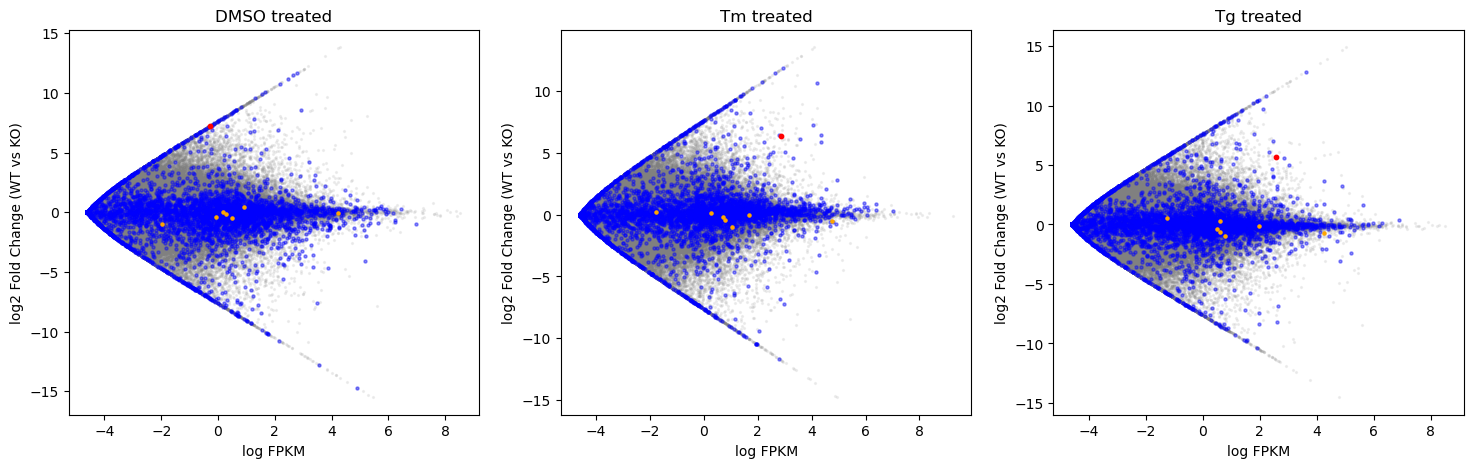

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.chdir('/data2/zhoulab/fanweiliang/mouse_IER1_splicing')

samples = ['WT_DMSO', 'KO_DMSO', 'WT_Tm', 'KO_Tm', 'WT_Tg', 'KO_Tg']

stringtie_transcripts = pd.DataFrame()
for i, sample in enumerate(samples):
    if i == 0:
        stringtie_transcripts = pd.read_csv(
            f'results/hela_tm_tg_mix/stringtie_viral_porechopabi/{sample}/t_data.ctab',
            sep='\t', usecols=['chr', 'start', 'end', 't_id', 't_name', 'gene_id', 'FPKM'], index_col='t_id'
        )
        stringtie_transcripts.rename(columns={'FPKM': sample}, inplace=True)
    else:
        tmp_transcripts = pd.read_csv(
            f'results/hela_tm_tg_mix/stringtie_viral_porechopabi/{sample}/t_data.ctab',
            sep='\t', usecols=['t_id', 'FPKM'], index_col='t_id'
        )
        stringtie_transcripts[sample] = tmp_transcripts['FPKM']

for i, experiment in enumerate(['DMSO', 'Tm', 'Tg']):
    stringtie_transcripts[f'{experiment}_fold_change'] = (stringtie_transcripts[f'WT_{experiment}'] + 0.01) / (stringtie_transcripts[f'KO_{experiment}'] + 0.01)
    stringtie_transcripts[f'{experiment}_log2FC'] = np.log2(stringtie_transcripts[f'{experiment}_fold_change'])
    stringtie_transcripts[f'{experiment}_mean_FPKM'] = stringtie_transcripts[[f'WT_{experiment}', f'KO_{experiment}']].mean(axis=1)
    stringtie_transcripts[f'{experiment}_logFPKM'] = stringtie_transcripts[f'{experiment}_mean_FPKM'].apply(lambda x: np.log(x + 0.01))

plt.figure(figsize=(18, 5))

for i, experiment in enumerate(['DMSO', 'Tm', 'Tg']):
    # Filter out transcripts with zero FPKM in both conditions
    # plot_df = plot_df[(plot_df[['WT', 'KO']] != 0).any(axis=1)]

    # MA plot
    plot_df = stringtie_transcripts[[f'{experiment}_logFPKM', f'{experiment}_log2FC', 't_name', 'gene_id']].copy()
    plot_df.columns = ['logFPKM', 'log2FC', 't_name', 'gene_id']
    # highlight some points
    nc_points = plot_df[plot_df['t_name'].isin(nc_transcripts_ids)].copy()
    xbp1_points = plot_df[plot_df['gene_id'] == 'MSTRG.22477'].copy()
    xbp1s_point = plot_df[plot_df['t_name'] == 'ENST00000344347.6'].copy()

    plt.subplot(1, 3, i + 1)
    plt.scatter(plot_df['logFPKM'], plot_df['log2FC'], alpha=0.1, color='gray', s=2)
    plt.scatter(nc_points['logFPKM'], nc_points['log2FC'], alpha=0.4, color='blue', s=5)
    plt.scatter(xbp1_points['logFPKM'], xbp1_points['log2FC'], color='orange', s=5)
    plt.scatter(xbp1s_point['logFPKM'], xbp1s_point['log2FC'], color='red', s=10)
    plt.xlabel('log FPKM')
    plt.ylabel('log2 Fold Change (WT vs KO)')
    plt.title(f'{experiment} treated')

plt.show()


In [5]:
nc_fpkm = stringtie_transcripts[stringtie_transcripts['t_name'].isin(nc_transcripts_ids)].copy()
nc_fpkm = nc_fpkm[nc_fpkm['chr'].str.startswith('chr')]
nc_fpkm = nc_fpkm[nc_fpkm[['DMSO_mean_FPKM', 'Tm_mean_FPKM', 'Tg_mean_FPKM']].sum(axis=1) > 0.1]
nc_fpkm = nc_fpkm[(nc_fpkm['Tm_log2FC'] > 1.5) & (nc_fpkm['Tg_log2FC'] > 1.5)]
nc_fpkm.sort_values(by='Tm_log2FC', inplace=True, ascending=False)

nc_fpkm

,chr,start,end,t_name,gene_id,WT_DMSO,KO_DMSO,WT_Tm,KO_Tm,WT_Tg,...,DMSO_mean_FPKM,DMSO_logFPKM,Tm_fold_change,Tm_log2FC,Tm_mean_FPKM,Tm_logFPKM,Tg_fold_change,Tg_log2FC,Tg_mean_FPKM,Tg_logFPKM
t_id,,,,,,,,,,,,,,,,,,,,,
111980,chr12,53441730,53446660,MSTRG.9003.5,MSTRG.9003,0.500513,1.361858,132.489914,0.072012,0.111908,...,0.931185,-0.060615,1615.616178,10.657869,66.280963,4.194054,12.190800,3.607721,0.055954,-2.718798
119588,chr12,98593677,98606379,MSTRG.9470.16,MSTRG.9470,4.449060,0.000000,6.264146,0.000000,0.112335,...,2.224530,0.804031,627.414600,9.293275,3.132073,1.144883,12.233500,3.612765,0.056168,-2.715566
413332,chr6,34236897,34246236,MSTRG.28301.26,MSTRG.28301,7.458291,0.000000,5.036865,0.000000,7.292788,...,3.729146,1.318857,504.686500,8.979244,2.518432,0.927600,83.019246,6.375374,3.685376,1.307082
95036,chr11,108121530,108148957,MSTRG.7831.2,MSTRG.7831,4.317444,9.503353,4.241210,0.000000,7.511783,...,6.910399,1.934473,425.121000,8.731730,2.120605,0.756406,752.178300,9.554931,3.755892,1.325985
497511,chr9,130444959,130501312,MSTRG.33535.18,MSTRG.33535,0.052863,0.790819,3.580462,0.000000,0.652082,...,0.421841,-0.839698,359.046200,8.488026,1.790231,0.587915,3.044041,1.605988,0.429791,-0.821455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278991,chr2,142877410,143055833,MSTRG.20028.2,MSTRG.20028,2.769307,5.407736,2.443869,0.766024,2.989197,...,4.088521,1.410626,3.162105,1.660885,1.604947,0.479302,4.150724,2.053363,1.850884,0.621052
495113,chr9,122941009,123104869,MSTRG.33340.7,MSTRG.33340,0.000000,0.550450,4.480880,1.509822,4.880187,...,0.275225,-1.254477,2.954872,1.563096,2.995351,1.100394,489.018700,8.933746,2.440094,0.896126
75954,chr11,6603773,6610874,MSTRG.6619.20,MSTRG.6619,5.096869,23.112258,0.328705,0.105174,12.140101,...,14.104564,2.647207,2.940811,1.556214,0.216940,-1.483072,195.868278,7.613740,6.096067,1.809283
